# E-Commerce Sales Analysis

This project analyzes e-commerce sales data to identify trends and patterns in sales, profit, quantity, categories, regions, and products.

In [1]:
print("E-Commerce Sales Analysis")

E-Commerce Sales Analysis


### 1. Importing Libraries

In [2]:
import pandas as pd

### 2. Loading the Dataset

In [3]:
data = pd.read_csv("ecommerce_sales_data (2).csv")

### 3. Initial Data Exploration

In [4]:
data.head()

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
0,2024-12-31,Printer,Office,North,4,3640,348.93
1,2022-11-27,Mouse,Accessories,East,7,1197,106.53
2,2022-05-11,Tablet,Electronics,South,5,5865,502.73
3,2024-03-16,Mouse,Accessories,South,2,786,202.87
4,2022-09-10,Mouse,Accessories,West,1,509,103.28


In [5]:
data.shape

(3500, 7)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order Date    3500 non-null   object 
 1   Product Name  3500 non-null   object 
 2   Category      3500 non-null   object 
 3   Region        3500 non-null   object 
 4   Quantity      3500 non-null   int64  
 5   Sales         3500 non-null   int64  
 6   Profit        3500 non-null   float64
dtypes: float64(1), int64(2), object(4)
memory usage: 191.5+ KB


In [7]:
data.describe()

,Quantity,Sales,Profit
count,3500.000000,3500.000000,3500.000000
mean,4.931714,3047.966000,527.047203
std,2.575895,2440.213237,504.139732
min,1.000000,51.000000,6.970000
25%,3.000000,1049.500000,158.695000
50%,5.000000,2350.500000,361.070000
75%,7.000000,4537.000000,729.125000
max,9.000000,10782.000000,2946.930000


### 4. Data Quality Check

In [8]:
data.isnull().sum()

Order Date      0
Product Name    0
Category        0
Region          0
Quantity        0
Sales           0
Profit          0
dtype: int64

In [9]:
data.duplicated().sum()

np.int64(0)

### 5. Date Conversion and Time Range

In [10]:
data['Order Date'] = pd.to_datetime(data['Order Date'])

In [11]:
data['Order Date'].min() , data['Order Date'].max()

(Timestamp('2022-01-01 00:00:00'), Timestamp('2024-12-31 00:00:00'))

### 6. Overall Sales and Profit

In [12]:
data[['Sales','Profit']].sum()

Sales     10667881.00
Profit     1844665.21
dtype: float64

### 7. Category Analysis

In [13]:
data.groupby('Category')['Sales'].sum().sort_values(ascending=False)

Category
Electronics    5326074
Accessories    4247591
Office         1094216
Name: Sales, dtype: int64

In [14]:
data.groupby('Category')['Profit'].sum().sort_values(ascending=False)

Category
Electronics    923185.59
Accessories    736084.74
Office         185394.88
Name: Profit, dtype: float64

In [15]:
category_performance = data.groupby('Category')[['Sales','Profit','Quantity']].sum()
category_performance['Profit Margin (%)'] = (category_performance['Profit']/category_performance['Sales'])*100
category_performance.sort_values('Profit Margin (%)', ascending=False)


,Sales,Profit,Quantity,Profit Margin (%)
Category,,,,
Electronics,5326074,923185.59,8610,17.333323
Accessories,4247591,736084.74,6917,17.329464
Office,1094216,185394.88,1734,16.943170


### 8. Regional Analysis

In [16]:
data.groupby('Region')['Sales'].sum().sort_values(ascending=False)

Region
West     2844450
East     2675110
South    2659548
North    2488773
Name: Sales, dtype: int64

In [17]:
data.groupby('Region')['Profit'].sum().sort_values(ascending=False)

Region
West     495358.73
East     464888.46
South    458103.27
North    426314.75
Name: Profit, dtype: float64

In [18]:
region_performance = data.groupby('Region')[['Sales','Profit','Quantity']].sum()
region_performance['Profit Margin (%)'] = (region_performance['Profit']/region_performance['Sales'])*100
region_performance.sort_values('Profit Margin (%)', ascending=False)

,Sales,Profit,Quantity,Profit Margin (%)
Region,,,,
West,2844450,495358.73,4488,17.414921
East,2675110,464888.46,4306,17.378293
South,2659548,458103.27,4361,17.224854
North,2488773,426314.75,4106,17.129515


### 9. Product Analysis

In [19]:
data.groupby('Product Name')['Sales'].sum().sort_values(ascending=False)

Product Name
Camera        1177381
Monitor       1160048
Printer       1094216
Mouse         1074398
Smartphone    1069681
Smartwatch    1049211
Keyboard      1024507
Tablet        1023928
Laptop        1005873
Headphones     988638
Name: Sales, dtype: int64

In [20]:
data.groupby('Product Name')['Profit'].sum().sort_values(ascending=False)

Product Name
Camera        207630.99
Monitor       202028.17
Mouse         185763.69
Laptop        185756.81
Printer       185394.88
Smartphone    183296.97
Smartwatch    178995.81
Keyboard      175814.68
Headphones    172478.20
Tablet        167505.01
Name: Profit, dtype: float64

In [21]:
data.groupby('Product Name')['Quantity'].sum().sort_values(ascending=False)

Product Name
Monitor       1876
Smartwatch    1807
Camera        1795
Mouse         1753
Printer       1734
Tablet        1733
Keyboard      1684
Laptop        1658
Smartphone    1617
Headphones    1604
Name: Quantity, dtype: int64

In [22]:
data.groupby('Product Name')[['Quantity','Sales','Profit']].sum().sort_values('Profit',ascending=False)

,Quantity,Sales,Profit
Product Name,,,
Camera,1795,1177381,207630.99
Monitor,1876,1160048,202028.17
Mouse,1753,1074398,185763.69
Laptop,1658,1005873,185756.81
Printer,1734,1094216,185394.88
Smartphone,1617,1069681,183296.97
Smartwatch,1807,1049211,178995.81
Keyboard,1684,1024507,175814.68
Headphones,1604,988638,172478.20


In [23]:
product_analysis = data.groupby('Product Name')[['Quantity','Sales','Profit']].sum().sort_values('Profit',ascending=False)

### 10. Monthly Sales and Profit Analysis

In [24]:
data['Year-Month'] = data['Order Date'].dt.to_period('M')
monthly_analysis = data.groupby('Year-Month')[['Sales','Profit']].sum()
data.groupby('Year-Month')['Sales'].sum().sort_values(ascending=False)

Year-Month
2023-08    388428
2023-12    375064
2024-05    373911
2023-05    346481
2023-01    343256
2024-09    341926
2024-03    341563
2022-01    341544
2024-12    324997
2022-10    324989
2023-07    320798
2022-05    314295
2024-06    314268
2024-10    314135
2023-02    313931
2024-04    310444
2024-07    309515
2023-11    306195
2023-09    303409
2023-03    303391
2022-08    296242
2022-03    294660
2024-11    291769
2024-01    282814
2023-04    280808
2022-06    273851
2022-12    259041
2022-11    257111
2023-10    253145
2023-06    251686
2024-08    240269
2022-09    240211
2022-04    230624
2022-07    214627
2022-02    208775
2024-02    179708
Freq: M, Name: Sales, dtype: int64

In [25]:
data.groupby('Year-Month')['Profit'].sum().sort_values(ascending=False)

Year-Month
2023-12    75505.76
2023-08    65590.62
2022-01    63827.33
2023-01    63708.78
2024-05    60700.45
2023-05    59087.73
2024-09    57851.73
2024-03    56762.15
2024-10    55594.98
2023-07    55207.40
2024-07    54026.44
2023-02    53645.43
2024-12    53592.79
2022-05    53504.97
2023-03    53442.67
2022-10    52927.24
2023-11    52537.37
2024-04    52181.84
2022-03    51931.81
2024-06    51261.85
2023-09    51010.49
2022-11    50120.69
2024-01    49744.18
2023-04    49178.67
2022-06    48490.93
2022-08    47551.99
2022-12    44743.58
2023-10    44505.75
2022-04    44260.45
2023-06    43445.75
2024-11    42179.73
2022-09    41402.82
2022-07    40010.27
2024-08    39817.28
2022-02    34084.90
2024-02    31228.39
Freq: M, Name: Profit, dtype: float64

### 11. Yearly Sales and Profit Analysis

In [26]:
data['Year'] = data['Order Date'].dt.year
data.groupby('Year')['Sales'].sum().sort_values(ascending=False)

Year
2023    3786592
2024    3625319
2022    3255970
Name: Sales, dtype: int64

In [27]:
yearly_analysis = data.groupby('Year')[['Sales','Profit']].sum()

In [28]:
data.groupby('Year')['Profit'].sum().sort_values(ascending=False)

Year
2023    666866.42
2024    604941.81
2022    572856.98
Name: Profit, dtype: float64

### 12. Product Profibility Analysis

In [ ]:
product_performance = data.groupby('Product Name')[['Sales','Profit','Quantity']].sum()
product_performance['Profit Margin (%)'] = (product_performance['Profit']/product_performance['Sales'])*100
product_performance.sort_values('Profit Margin (%)', ascending=False)

,Sales,Profit,Quantity,Profit Margin (%)
Product Name,,,,
Laptop,1005873,185756.81,1658,18.467223
Camera,1177381,207630.99,1795,17.634987
Headphones,988638,172478.20,1604,17.446042
Monitor,1160048,202028.17,1876,17.415501
Mouse,1074398,185763.69,1753,17.290026
Keyboard,1024507,175814.68,1684,17.160906
Smartphone,1069681,183296.97,1617,17.135667
Smartwatch,1049211,178995.81,1807,17.060039
Printer,1094216,185394.88,1734,16.943170


### 13. Data Visualization

In [29]:
import matplotlib.pyplot as plt

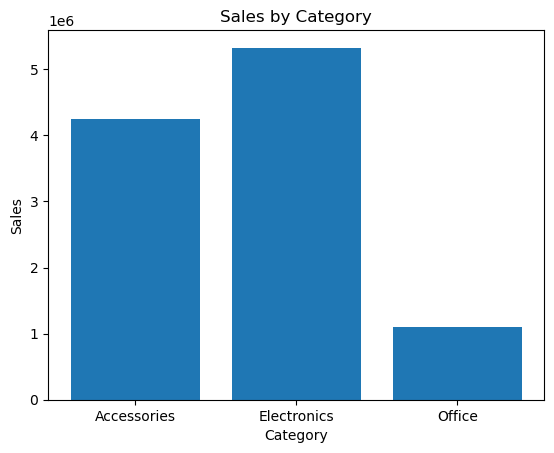

In [30]:
plt.bar(category_performance.index, category_performance['Sales'])

plt.xlabel('Category')
plt.ylabel('Sales')
plt.title('Sales by Category')

plt.show()

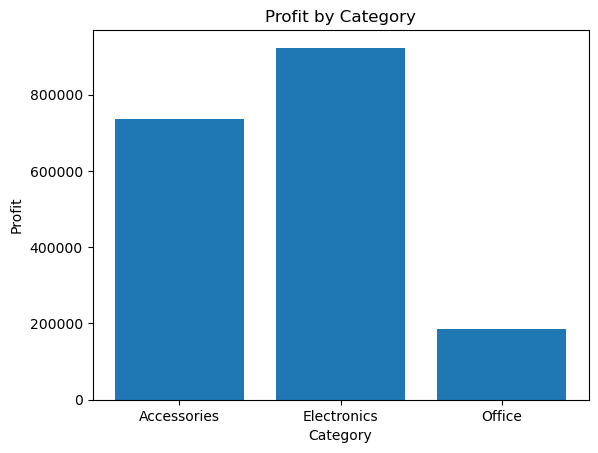

In [31]:
plt.bar(category_performance.index, category_performance['Profit'])

plt.xlabel('Category')
plt.ylabel('Profit')
plt.title('Profit by Category')

plt.show()

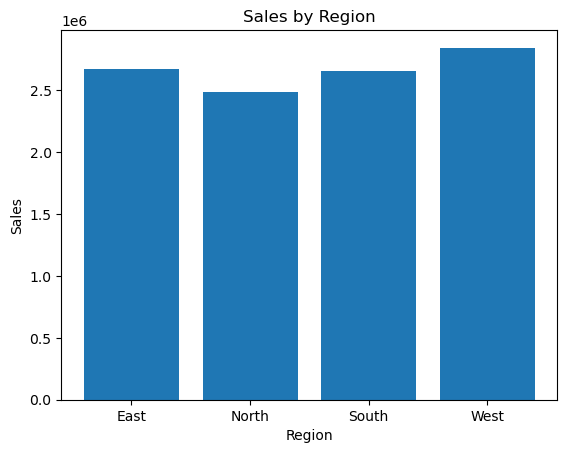

In [32]:
plt.bar(region_performance.index, region_performance['Sales'])

plt.xlabel('Region')
plt.ylabel('Sales')
plt.title('Sales by Region')

plt.show()

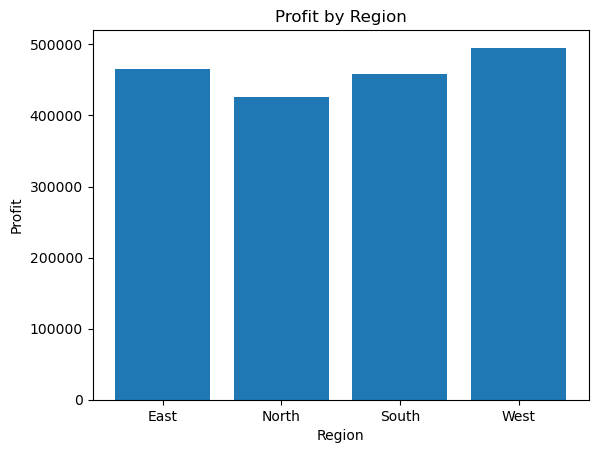

In [33]:
plt.bar(region_performance.index, region_performance['Profit'])

plt.xlabel('Region')
plt.ylabel('Profit')
plt.title('Profit by Region')

plt.show()

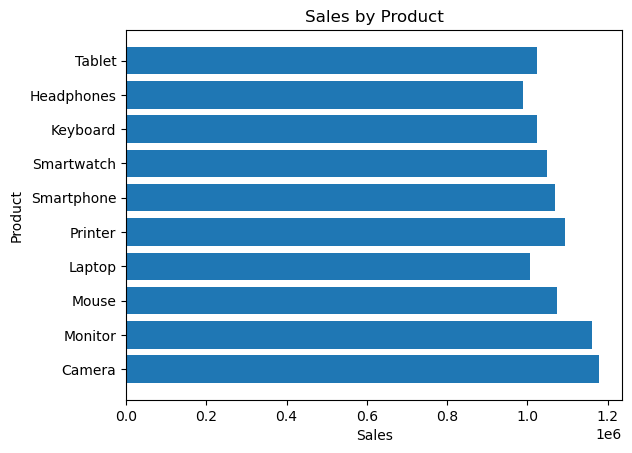

In [34]:
plt.barh(product_analysis.index,product_analysis['Sales'])

plt.ylabel('Product')
plt.xlabel('Sales')
plt.title('Sales by Product')


plt.show()

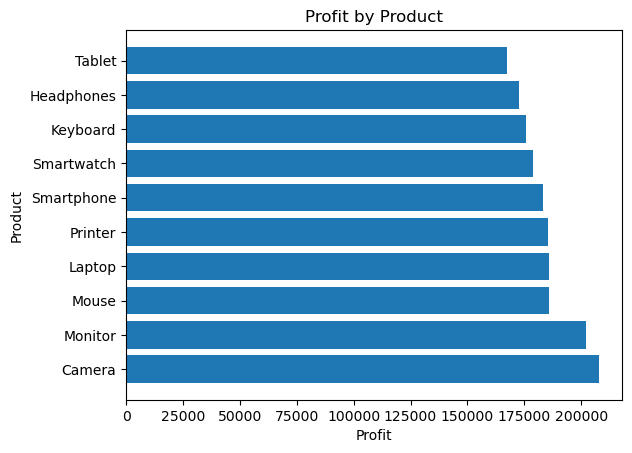

In [35]:
plt.barh(product_analysis.index,product_analysis['Profit'])

plt.ylabel('Product')
plt.xlabel('Profit')
plt.title('Profit by Product')


plt.show()

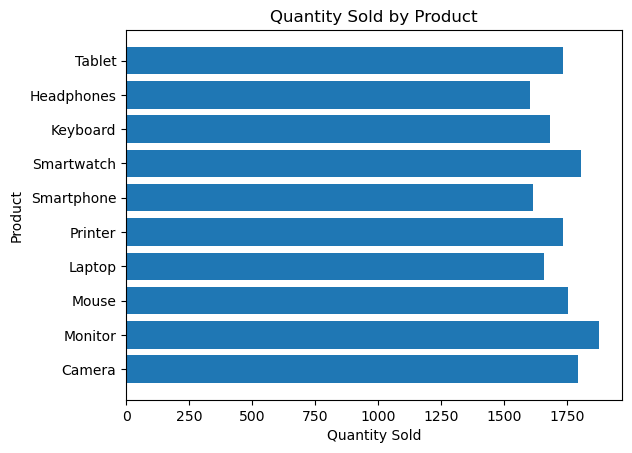

In [36]:
plt.barh(product_analysis.index,product_analysis['Quantity'])

plt.ylabel('Product')
plt.xlabel('Quantity Sold')
plt.title('Quantity Sold by Product')


plt.show()

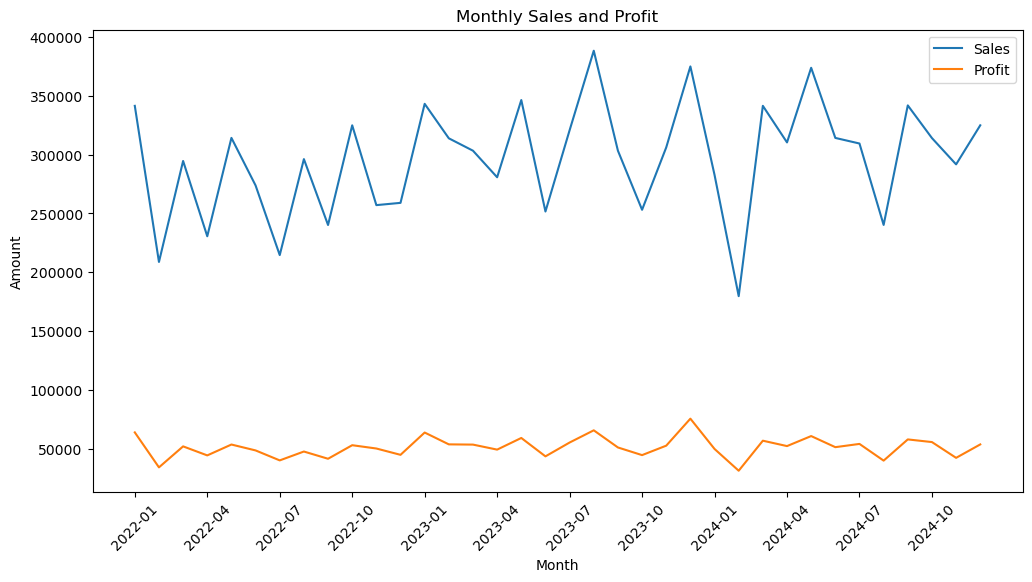

In [37]:
plt.figure(figsize=(12,6))
plt.plot(monthly_analysis.index.astype(str),monthly_analysis['Sales'],label='Sales')
plt.plot(monthly_analysis.index.astype(str),monthly_analysis['Profit'],label='Profit')

plt.xlabel('Month')
plt.ylabel('Amount')
plt.title('Monthly Sales and Profit')
plt.xticks(range(0, len(monthly_analysis), 3),monthly_analysis.index.astype(str)[::3],rotation=45)
plt.legend()
plt.show()

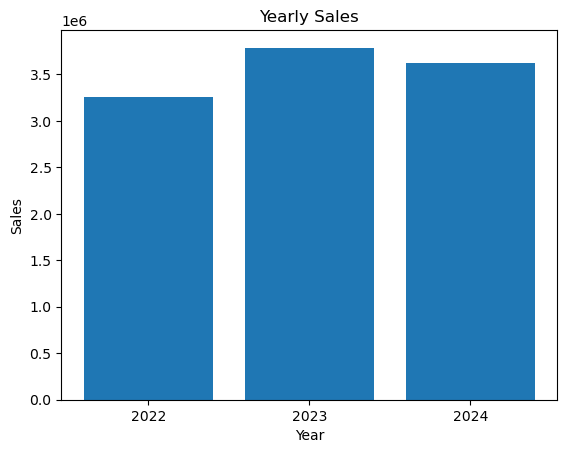

In [38]:
plt.bar(yearly_analysis.index,yearly_analysis['Sales'])
plt.xlabel('Year')
plt.ylabel('Sales')
plt.title('Yearly Sales')
plt.xticks(yearly_analysis.index)
plt.show()

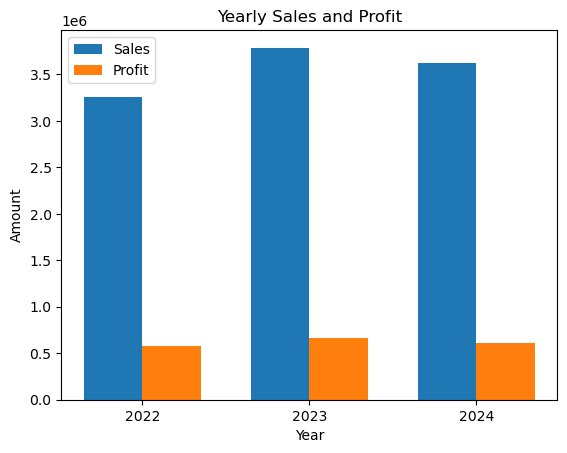

In [39]:
width = 0.35
plt.bar(yearly_analysis.index,yearly_analysis['Sales'],width=width, label='Sales')
plt.bar((yearly_analysis.index)+width,yearly_analysis['Profit'],width=width, label='Profit')

plt.xlabel('Year')
plt.ylabel('Amount')
plt.title('Yearly Sales and Profit')
plt.xticks(yearly_analysis.index+width/2,yearly_analysis.index)
plt.legend()
plt.show()

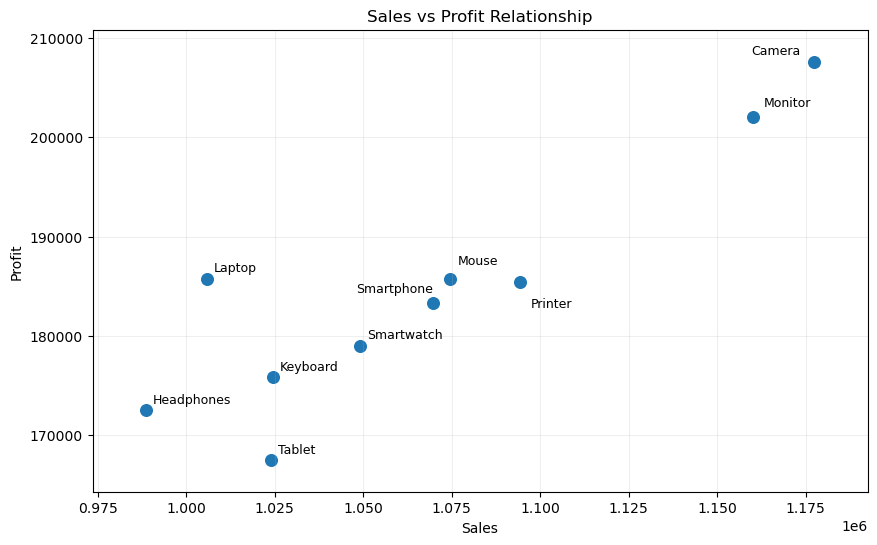

In [40]:
plt.figure(figsize=(10, 6))
plt.scatter(product_analysis['Sales'],product_analysis['Profit'],s=70)
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.title('Sales vs Profit Relationship')
offsets = {
    'Camera': (-45, 5),
    'Monitor': (8, 8),
    'Mouse': (6, 10),
    'Smartphone': (-55, 8),
    'Printer': (8, -18)
}
for product_name,row in product_analysis.iterrows():
    Sales = row['Sales']
    Profit = row['Profit']
    
    plt.annotate(product_name,(Sales,Profit),xytext=offsets.get(product_name, (5,5)),textcoords='offset points',fontsize=9)
plt.margins(x=0.08, y=0.08)
plt.grid(alpha=0.2)
plt.show()

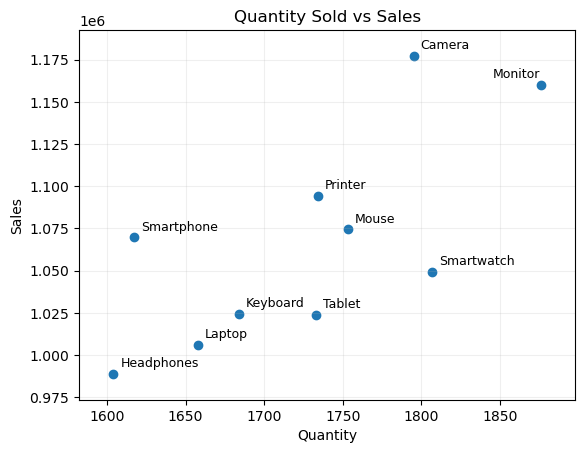

In [41]:
plt.scatter(product_analysis['Quantity'],product_analysis['Sales'])
plt.xlabel('Quantity')
plt.ylabel('Sales')
plt.title('Quantity Sold vs Sales')
offsets = {'Monitor': (-35, 5),}
for product_name,row in product_analysis.iterrows():
    Quantity = row['Quantity']
    Sales = row['Sales']
    plt.annotate(product_name,(Quantity,Sales),xytext=offsets.get(product_name, (5,5)),textcoords='offset points',fontsize=9)
plt.margins(x=0.08, y=0.08)
plt.grid(alpha=0.2)
plt.show()

### 14. Key Business Insights

#### 1. Product Performance
Camera is the strongest-performing product, generating the highest sales and profit. Monitor has the highest quantity sold, indicating strong demand in terms of units. Tablet has the lowest profit among the products analyzed.

#### 2. Category Performance
Electronics is the strongest-performing category, generating the highest sales, profit, and quantity sold. In contrast, Office has the lowest profit among the categories analyzed.

#### 3. Regional Performance 
West is the strongest-performing region, recording the highest sales, profit, and quantity sold. In contrast, North has the lowest profit among the regions analyzed.

#### 4. Yearly Performance
2023 was the strongest-performing year, recording the highest sales and profit, while 2022 recorded the lowest sales and profit among the years analyzed.

#### 5. Monthly Performance
August 2023 recorded the highest monthly sales, while February 2024 recorded the lowest sales and lowest profit. December 2023 achieved the highest monthly profit, indicating particularly strong profitability during that month.

#### 6. Product Profit Analysis
Camera generates the highest sales, but Laptop has the highest profit margin. This indicates that strong sales volume does not necessarily translate into the highest profitability relative to sales.